<a href="https://colab.research.google.com/github/PrinceThekkedath/ds-projects-hub/blob/main/Road_lane_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
from google.colab import files
from moviepy import editor
import moviepy

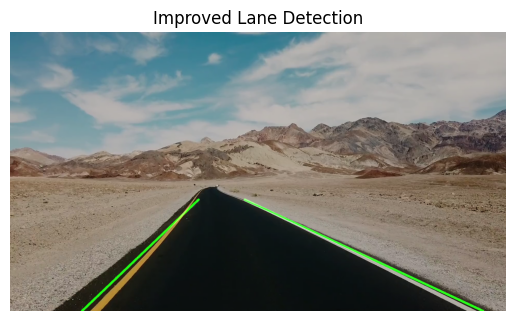

KeyboardInterrupt: 

In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

def region_of_interest(img):
    height, width = img.shape
    mask = np.zeros_like(img)

    # Custom trapezoid ROI (exclude car at bottom, focus on lane region)
    polygon = np.array([[
        (int(0.1 * width), int(0.95 * height)),
        (int(0.9 * width), int(0.95 * height)),
        (int(0.6 * width), int(0.6 * height)),
        (int(0.4 * width), int(0.6 * height))
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image

# Helper to average lane lines
def average_slope_intercept(lines, img_shape):
    left_lines = []
    right_lines = []

    for line in lines:
        for x1, y1, x2, y2 in line:
            if x2 - x1 == 0:  # Avoid division by zero
                continue
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1
            if slope < -0.3:
                left_lines.append((slope, intercept))
            elif slope > 0.3:
                right_lines.append((slope, intercept))

    lane_lines = []
    for group in [left_lines, right_lines]:
        if group:
            slope_avg, intercept_avg = np.mean(group, axis=0)
            y1 = img_shape[0]
            y2 = int(img_shape[0] * 0.6)
            x1 = int((y1 - intercept_avg) / slope_avg)
            x2 = int((y2 - intercept_avg) / slope_avg)
            lane_lines.append([[x1, y1, x2, y2]])

    return lane_lines

def draw_lines(img, lines):
    line_img = np.zeros_like(img)
    if lines:
        for x1, y1, x2, y2 in lines[0]:
            cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 8)
        if len(lines) > 1:
            for x1, y1, x2, y2 in lines[1]:
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 8)
    return line_img

# Video path
video_path = '/content/3059073-hd_1920_1080_24fps.mp4'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blur, 70, 200)
        masked = region_of_interest(edges)

        lines = cv2.HoughLinesP(masked, 1, np.pi / 180, threshold=40, minLineLength=50, maxLineGap=150)

        if lines is not None:
            averaged_lines = average_slope_intercept(lines, frame.shape)
            line_img = draw_lines(frame, averaged_lines)
        else:
            line_img = np.zeros_like(frame)

        combined = cv2.addWeighted(frame, 0.8, line_img, 1, 1)

        plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Improved Lane Detection')
        plt.show()

        time.sleep(0.5)
        clear_output(wait=True)

cap.release()


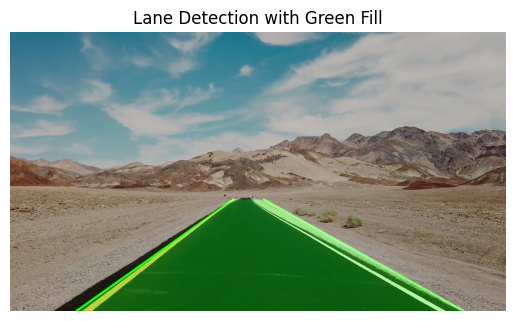

In [34]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

def region_of_interest(img):
    height, width = img.shape
    mask = np.zeros_like(img)
    polygon = np.array([[
        (int(0.1 * width), int(0.95 * height)),
        (int(0.9 * width), int(0.95 * height)),
        (int(0.6 * width), int(0.6 * height)),
        (int(0.4 * width), int(0.6 * height))
    ]], np.int32)
    cv2.fillPoly(mask, polygon, 255)
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image

def average_slope_intercept(lines, img_shape):
    left_lines = []
    right_lines = []

    for line in lines:
        for x1, y1, x2, y2 in line:
            if x2 - x1 == 0:
                continue
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1
            if slope < -0.3:
                left_lines.append((slope, intercept))
            elif slope > 0.3:
                right_lines.append((slope, intercept))

    lane_lines = []
    for group in [left_lines, right_lines]:
        if group:
            slope_avg, intercept_avg = np.mean(group, axis=0)
            y1 = img_shape[0]
            y2 = int(img_shape[0] * 0.6)
            x1 = int((y1 - intercept_avg) / slope_avg)
            x2 = int((y2 - intercept_avg) / slope_avg)
            lane_lines.append([[x1, y1, x2, y2]])

    return lane_lines

def draw_lane_fill(img, lines):
    if len(lines) < 2:
        return np.zeros_like(img)

    left = lines[0][0]
    right = lines[1][0]

    poly_points = np.array([[
        (left[0], left[1]),  # bottom left
        (left[2], left[3]),  # top left
        (right[2], right[3]),  # top right
        (right[0], right[1])   # bottom right
    ]], dtype=np.int32)

    fill_img = np.zeros_like(img)
    cv2.fillPoly(fill_img, poly_points, (0, 255, 0))  # green fill
    return fill_img

def draw_lines(img, lines):
    line_img = np.zeros_like(img)
    if lines:
        for x1, y1, x2, y2 in lines[0]:
            cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 8)
        if len(lines) > 1:
            for x1, y1, x2, y2 in lines[1]:
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 8)
    return line_img

# Video processing
video_path = '/content/3059073-hd_1920_1080_24fps.mp4'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blur, 70, 200)
        masked = region_of_interest(edges)

        lines = cv2.HoughLinesP(masked, 1, np.pi / 180, threshold=40, minLineLength=50, maxLineGap=150)

        line_img = np.zeros_like(frame)
        lane_fill = np.zeros_like(frame)

        if lines is not None:
            averaged_lines = average_slope_intercept(lines, frame.shape)
            line_img = draw_lines(frame, averaged_lines)
            lane_fill = draw_lane_fill(frame, averaged_lines)

        # Combine overlays
        combined = cv2.addWeighted(frame, 0.8, lane_fill, 0.3, 1)  # fill is more transparent
        combined = cv2.addWeighted(combined, 1, line_img, 1, 1)

        plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Lane Detection with Green Fill')
        plt.show()

        time.sleep(0.3)
        clear_output(wait=True)

cap.release()